# Amazon India Sales Analysis

## Business Problem
Amazon wants to understand product performance across 
categories to optimize pricing, discounts, and 
product recommendations.

## Dataset
1465 products across 4 main categories:
Electronics, Computers&Accessories, Home&Kitchen, OfficeProducts

## Tools Used
Python, Pandas, Matplotlib, Seaborn

## Key Questions Answered
1. Which categories generate highest revenue potential?
2. Does discount % affect customer ratings?
3. Which categories have best rated products?
4. What discount range leads to highest ratings?
5. Which products offer best value to customers?

In [125]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [128]:
df = pd.read_csv('Amazon.csv')

In [8]:
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

In [12]:
df.describe()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
count,1465,1465,1465,1465,1465,1465,1465,1463,1465,1465,1465,1465,1465,1465,1465,1465
unique,1351,1337,211,550,449,92,28,1143,1293,1194,1194,1194,1194,1212,1412,1465
top,B07JW9H4J1,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",Computers&Accessories|Accessories&Peripherals|...,₹199,₹999,50%,4.1,"9,378",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AHIKJUDTVJ4T6DV6IUGFYZ5LXMPA,AE55KTFVNXYFD5FPY...","$@|\|TO$|-|,Sethu madhav,Akash Thakur,Burger P...","R3F4T5TRYPTMIG,R3DQIEC603E7AY,R1O4Z15FD40PV5,R...","Worked on iPhone 7 and didn’t work on XR,Good ...","I am not big on camera usage, personally. I wa...",https://m.media-amazon.com/images/I/413sCRKobN...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
freq,3,5,233,53,120,56,244,9,6,10,10,10,10,8,3,1


In [13]:
df.isnull().sum()

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

In [18]:
df['rating_count'] = df['rating_count'].str.replace(',', '').astype(float)

In [20]:
df['rating_count'] = df['rating_count'].fillna(df['rating_count'].median())

In [22]:
df.isnull().sum()

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           0
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

In [31]:
df['discounted_price'] = df['discounted_price'].str.replace('₹', '').str.replace(',', '').astype(float)

In [32]:
df['actual_price'] = df['actual_price'].str.replace('₹', '').str.replace(',', '').astype(float)

In [26]:
df['discount_percentage'] = df['discount_percentage'].str.replace('%', '').astype(float)

In [29]:
df['rating'] = pd.to_numeric(df['rating'], errors = 'coerce')

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1465 non-null   object 
 1   product_name         1465 non-null   object 
 2   category             1465 non-null   object 
 3   discounted_price     1465 non-null   float64
 4   actual_price         1465 non-null   float64
 5   discount_percentage  1465 non-null   float64
 6   rating               1464 non-null   float64
 7   rating_count         1465 non-null   float64
 8   about_product        1465 non-null   object 
 9   user_id              1465 non-null   object 
 10  user_name            1465 non-null   object 
 11  review_id            1465 non-null   object 
 12  review_title         1465 non-null   object 
 13  review_content       1465 non-null   object 
 14  img_link             1465 non-null   object 
 15  product_link         1465 non-null   o

In [34]:
df['revenue_potential'] = df['discounted_price'] * df['rating_count']

In [35]:
df['price_drop'] = df['actual_price'] - df['discounted_price']

In [36]:
df['main_category'] = df['category'].str.split('|').str[0]

In [79]:
df['main_category'].value_counts()
top_categories = ['Electronics', 'Computers&Accessories', 'Home&Kitchen', 'OfficeProducts']
df_filtered = df[df['main_category'].isin(top_categories)]
df

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link,revenue_potential,price_drop,main_category
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,64.0,4.2,24269.0,High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...,9683331.0,700.0,Computers&Accessories
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199.0,349.0,43.0,4.0,43994.0,"Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...,8754806.0,150.0,Computers&Accessories
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199.0,1899.0,90.0,3.9,7928.0,【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...,1577672.0,1700.0,Computers&Accessories
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,329.0,699.0,53.0,4.2,94363.0,The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...,31045427.0,370.0,Computers&Accessories
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,154.0,399.0,61.0,4.2,16905.0,[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...,2603370.0,245.0,Computers&Accessories
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1460,B08L7J3T31,Noir Aqua - 5pcs PP Spun Filter + 1 Spanner | ...,Home&Kitchen|Kitchen&HomeAppliances|WaterPurif...,379.0,919.0,59.0,4.0,1090.0,SUPREME QUALITY 90 GRAM 3 LAYER THIK PP SPUN F...,"AHITFY6AHALOFOHOZEOC6XBP4FEA,AFRABBODZJZQB6Z4U...","Prabha ds,Raghuram bk,Real Deal,Amazon Custome...","R3G3XFHPBFF0E8,R3C0BZCD32EIGW,R2EBVBCN9QPD9R,R...","Received the product without spanner,Excellent...","I received product without spanner,Excellent p...",https://m.media-amazon.com/images/I/41fDdRtjfx...,https://www.amazon.in/Noir-Aqua-Spanner-Purifi...,413110.0,540.0,Home&Kitchen
1461,B01M6453MB,Prestige Delight PRWO Electric Rice Cooker (1 ...,Home&Kitchen|Kitchen&HomeAppliances|SmallKitch...,2280.0,3045.0,25.0,4.1,4118.0,"2

# Which categories have highest revenue potential?


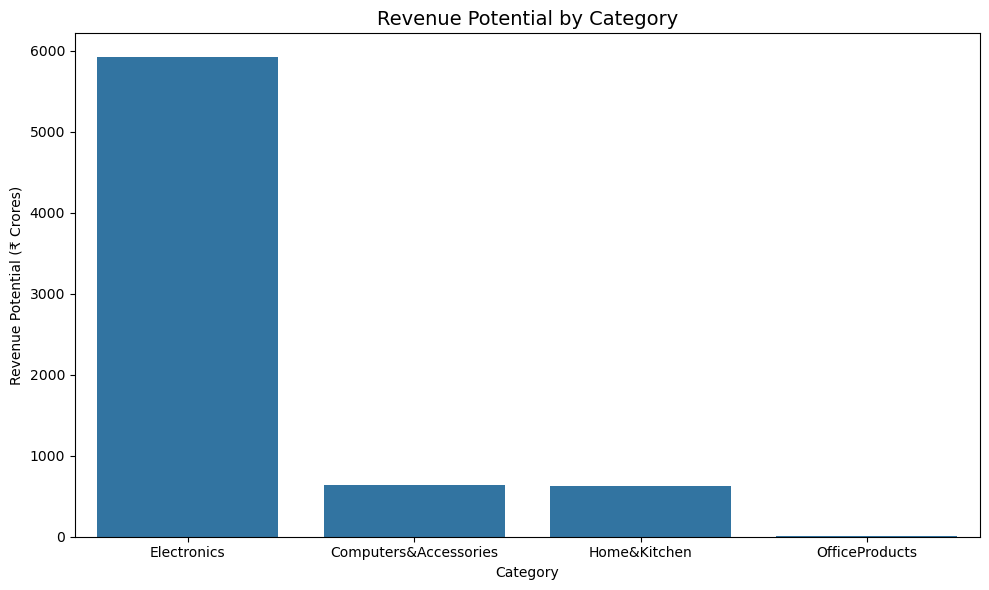

main_category
Electronics              5917.975342
Computers&Accessories     635.688914
Home&Kitchen              626.433618
OfficeProducts              4.578673
Name: revenue_potential, dtype: float64


In [66]:
category_revenue = df_filtered.groupby('main_category')['revenue_potential'].sum().sort_values(ascending = False)
category_revenue_cr = category_revenue / 10000000
plt.figure(figsize = (10,6))
sns.barplot(x = category_revenue_cr.index, y = category_revenue_cr.values)
plt.title('Revenue Potential by Category', fontsize = 14)
plt.xlabel('Category')
plt.ylabel('Revenue Potential (₹ Crores)')
plt.tight_layout()
plt.show()
print(category_revenue_cr)

# Does giving more discounts lead to better ratings?
 Here we create a relation between the discount percentage and ratings, from which we get to know whether the discount leads to better results or not

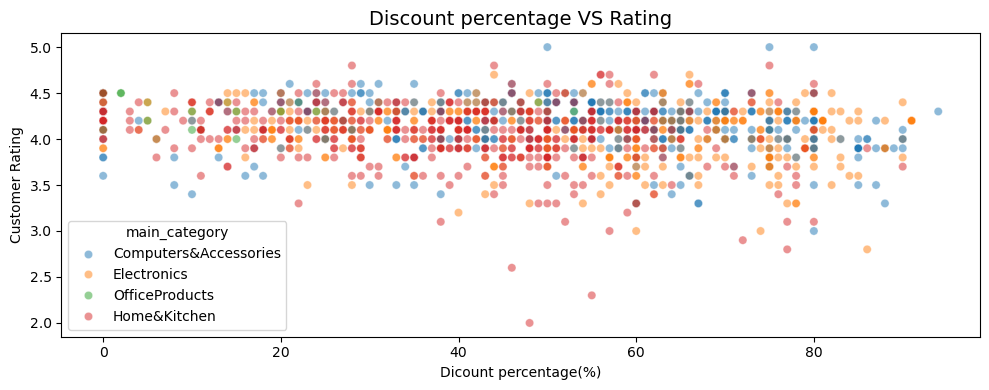

Correlation between discount percentage and rating is: -0.16


In [78]:
plt.figure(figsize = (10,4))
sns.scatterplot(data = df_filtered,
               x = 'discount_percentage',
               y = 'rating',
               hue = 'main_category',
               alpha = 0.5)
plt.title('Discount percentage VS Rating', fontsize = 14)
plt.xlabel('Dicount percentage(%)')
plt.ylabel('Customer Rating')
plt.tight_layout()
plt.show()

correlation = df_filtered['discount_percentage'].corr(df_filtered['rating'])
print(f"Correlation between discount percentage and rating is: {correlation:.2f}")

Most dots cluster between rating 3.8 to 4.5 across all discount levels(0% - 90%)
This means that discount % doesn't strongly determine whether a product is good or bad

# Which Categories Have Best Rated Products?


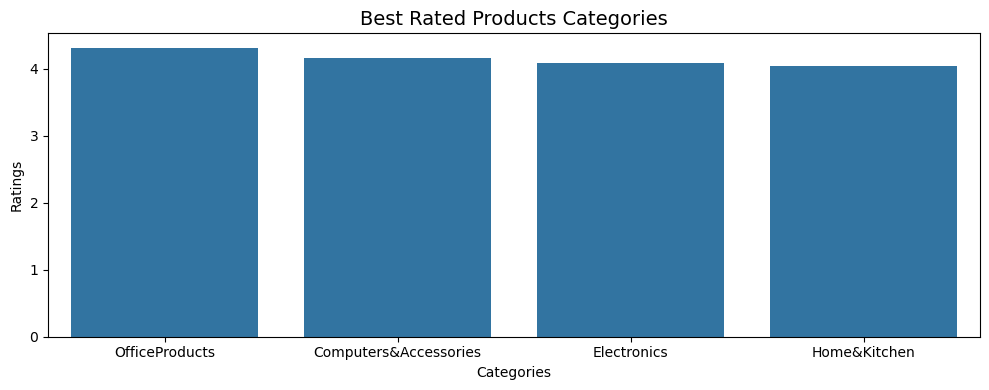

In [90]:
category_rating = df_filtered.groupby('main_category')['rating'].mean().sort_values(ascending = False)
plt.figure(figsize = (10,4))
sns.barplot(x = category_rating.index,
           y = category_rating.values)
plt.title('Best Rated Products Categories', fontsize = 14)
plt.xlabel('Categories')
plt.ylabel('Ratings')
plt.tight_layout()
plt.show()

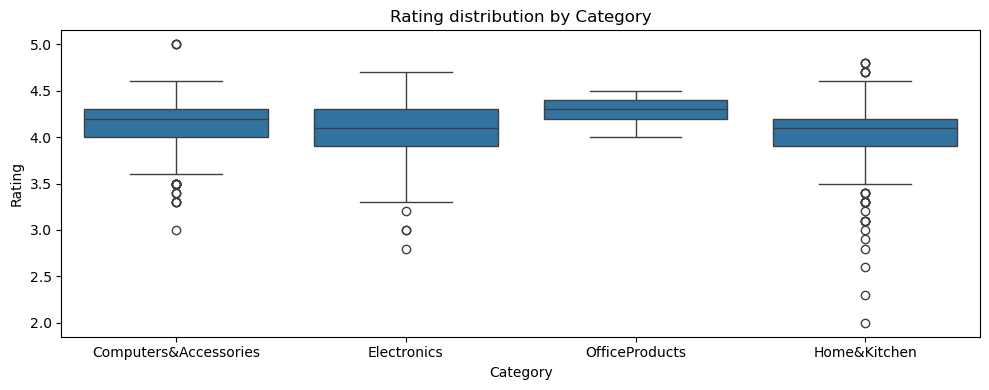

In [92]:
plt.figure(figsize = (10,4))
sns.boxplot(data = df_filtered, x = 'main_category', y = 'rating')
plt.title('Rating distribution by Category')
plt.xlabel('Category')
plt.ylabel('Rating')
plt.tight_layout()
plt.show()

# What Discount % Range Leads to Highest Ratings?


In [110]:
df_filtered.loc[:, 'discount_range'] = pd.cut(df_filtered['discount_percentage'],
                                      bins = [0, 20, 40, 60, 80, 100],
                                      labels = ['0 - 20%', '20 - 40%', '40 - 60%', '60 - 80%', '80 - 100%'])
# Average rating AND count of products per discount range
discount_analysis = df_filtered.groupby('discount_range').agg(
    avg_rating=('rating', 'mean'),
    product_count=('product_name', 'count'),
    avg_revenue=('revenue_potential', 'mean')
).reset_index()

print(discount_analysis)

  discount_range  avg_rating  product_count   avg_revenue
0        0 - 20%    4.146923            131  7.963587e+07
1       20 - 40%    4.127300            337  1.139843e+08
2       40 - 60%    4.079523            503  2.608509e+07
3       60 - 80%    4.076053            380  1.893620e+07
4      80 - 100%    3.976271             59  7.033777e+06


C:\Users\Raghav Ratan Yadav\AppData\Local\Temp\ipykernel_26012\2651394453.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  discount_analysis = df_filtered.groupby('discount_range').agg(


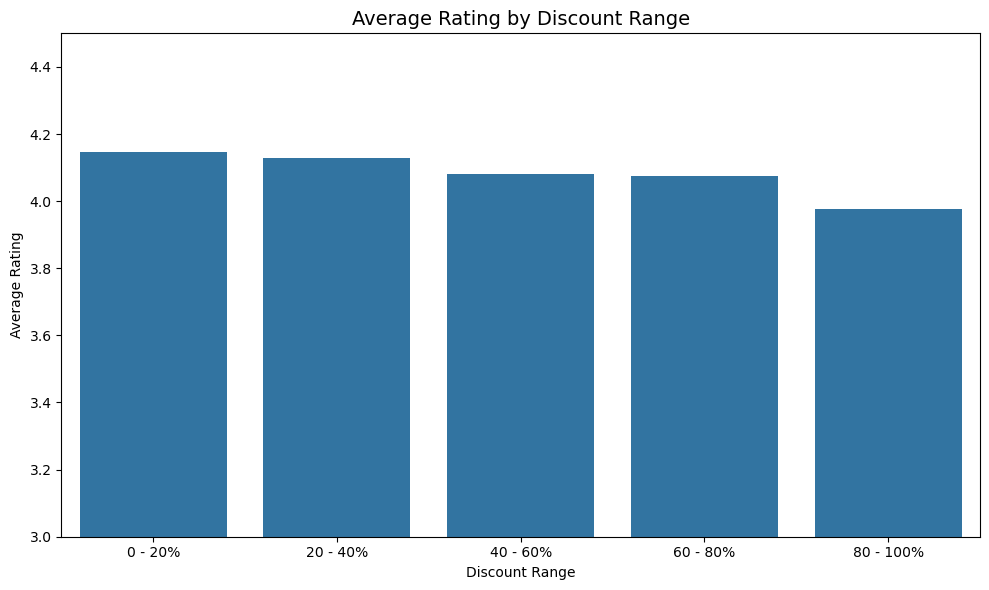

In [114]:
plt.figure(figsize=(10,6))
sns.barplot(x=discount_analysis['discount_range'], 
            y=discount_analysis['avg_rating'])
plt.title('Average Rating by Discount Range', fontsize=14)
plt.xlabel('Discount Range')
plt.ylabel('Average Rating')
plt.ylim(3,4.5)
plt.tight_layout()
plt.show()

# Number of products per discount range

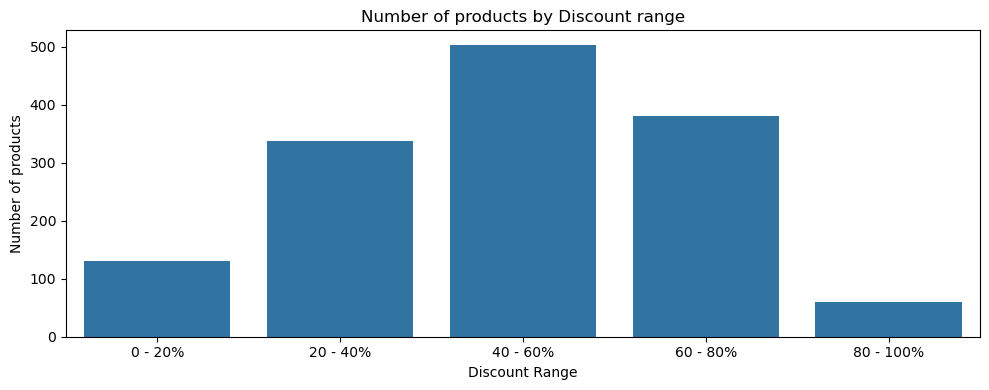

In [116]:
plt.figure(figsize = (10,4))
sns.barplot(x = discount_analysis['discount_range'],
           y = discount_analysis['product_count'])
plt.title('Number of products by Discount range')
plt.xlabel('Discount Range')
plt.ylabel('Number of products')
plt.tight_layout()
plt.show()

# Which Products Give Best Value?
The products which have high discounts and high ratings are best value for the customers,
i.e 
High rating + High discount = Best Value for Customers

In [121]:
best_value = df_filtered[(df_filtered['rating'] >= 4.0) & (df_filtered['discount_percentage'] > 50)].sort_values('rating', ascending = False)
print(best_value[['product_name', 'main_category', 
                   'discounted_price', 'actual_price',
                   'discount_percentage', 'rating', 
                   'rating_count']].head(10))

                                           product_name  \
324   REDTECH USB-C to Lightning Cable 3.3FT, [Apple...   
174   Syncwire LTG to USB Cable for Fast Charging Co...   
1299  Instant Pot Air Fryer, Vortex 2QT, Touch Contr...   
1226  Zuvexa USB Rechargeable Electric Foam Maker - ...   
1223  FIGMENT Handheld Milk Frother Rechargeable, 3-...   
1388  Campfire Spring Chef Prolix Instant Portable W...   
1275  Multifunctional 2 in 1 Electric Egg Boiling St...   
459   Spigen EZ Fit Tempered Glass Screen Protector ...   
571   WeCool S5 Long Selfie Stick, with Large Reinfo...   
1119  Lint Remover Woolen Clothes Lint Extractor Bat...   

              main_category  discounted_price  actual_price  \
324   Computers&Accessories             249.0         999.0   
174   Computers&Accessories             399.0        1999.0   
1299           Home&Kitchen            4995.0       20049.0   
1226           Home&Kitchen             499.0        1299.0   
1223           Home&Kitchen        

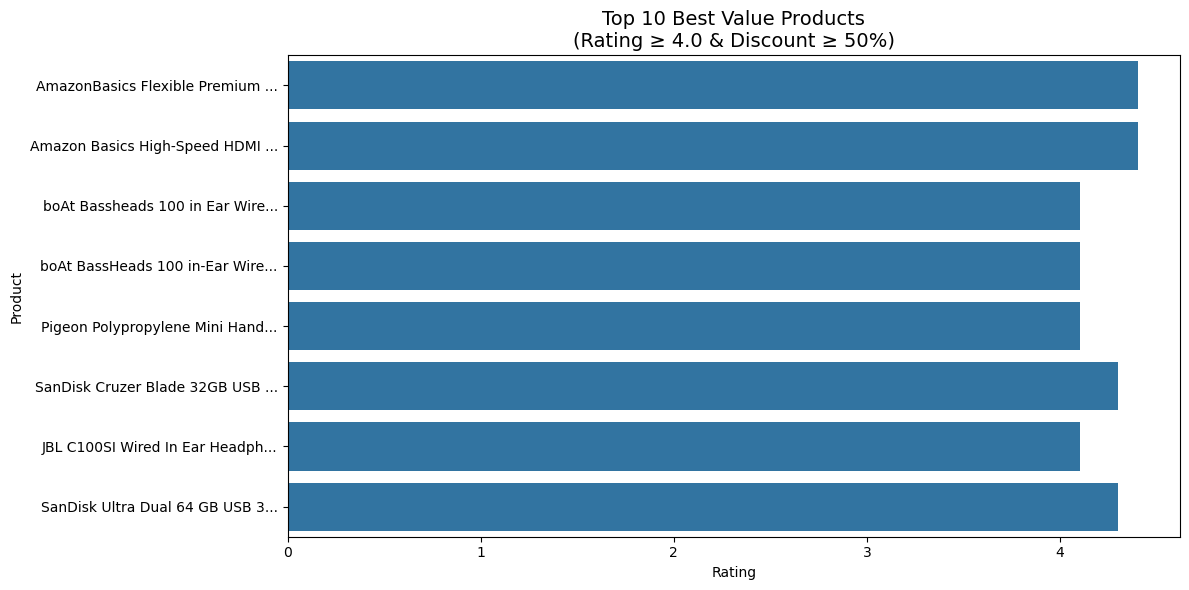

In [123]:
best_value['short_name'] = best_value['product_name'].str[:30] + '...'
top10 = best_value.nlargest(10, 'rating_count')

plt.figure(figsize=(12,6))
sns.barplot(data=top10, x='rating', y='short_name')
plt.title('Top 10 Best Value Products\n(Rating ≥ 4.0 & Discount ≥ 50%)', 
          fontsize=14)
plt.xlabel('Rating')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

In [124]:
worst_value = df_filtered[
    (df_filtered['rating'] < 3.5) & 
    (df_filtered['discount_percentage'] < 30)
].sort_values('rating')

print(f"Number of overpriced poor products: {len(worst_value)}")
print(worst_value[['product_name', 'main_category',
                    'discounted_price', 'discount_percentage', 
                    'rating']].head(5))

Number of overpriced poor products: 2
                                           product_name  \
1374  KNYUC MART Mini Electric Handy Room Heater Com...   
921   Canon PIXMA MG2577s All-in-One Inkjet Colour P...   

              main_category  discounted_price  discount_percentage  rating  
1374           Home&Kitchen             778.0                 22.0     3.3  
921   Computers&Accessories            3498.0                 10.0     3.4  


## Overall Business Recommendations

1. CATEGORY FOCUS → Electronics 
   drives ₹5900+ Crores in revenue

2. DISCOUNT STRATEGY → Heavy discounts don't 
   improve ratings. Focus discounts on driving 
   volume not satisfaction.

3. BEST CATEGORY FOR QUALITY → Office product
   has most consistent quality — promote these products more

4. BEST VALUE PRODUCTS → Products with 50%+ discount 
   AND 4.0+ rating are the sweet spot — 
   feature these prominently

5. REMOVE OR FIX → 2 products have low ratings 
   with minimal discount — poor value for customers